# Data Mining_2_Module_1
## Advanced Data Preprocessing: Outlier Detection & Imbalanced Learning
It starts from the final 30-column output of Module 0 and actually performs:

1. five-family top-1% outlier detection;
2. detector comparison and consensus voting;
3. severe-class inspection;
4. PCA and t-SNE visualization;
5. consensus-outlier removal and saving;
6. binary imbalanced-learning target construction;
7. one common train/test split and train-only scaling;
8. Decision Tree baseline;
9. undersampling, oversampling and class-weight experiments;
10. the final ADASYN + ENN combined approach;
11. saving of results and the dataset passed to Module 2.

## 0. Setup and project paths

Required packages beyond the standard scientific stack:

```bash
pip install pyod imbalanced-learn
```

In [2]:
pip install pyod imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imbalanced-learn][pyod]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from itertools import combinations
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.collections import LineCollection

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

try:
    from pyod.models.loda import LODA
    from pyod.models.knn import KNN
    from pyod.models.cblof import CBLOF
except ImportError as exc:
    raise ImportError("Install PyOD with: pip install pyod") from exc

try:
    from imblearn.under_sampling import (
        RandomUnderSampler,
        TomekLinks,
        EditedNearestNeighbours,
        ClusterCentroids,
    )
    from imblearn.over_sampling import (
        RandomOverSampler,
        SMOTE,
        ADASYN,
    )
except ImportError as exc:
    raise ImportError(
        "Install imbalanced-learn with: pip install imbalanced-learn"
    ) from exc

RANDOM_STATE = 42
SPLIT_RANDOM_STATE = 100

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def looks_like_project(path):
    return path.exists() and (
        (path / "data").exists()
        or (path / "cmi_internet.csv").exists()
        or (path / "05_final_tabular_dataset.csv").exists()
    )

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if looks_like_project(p)), None)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES."
    )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "module1"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed directory:", PROCESSED_DIR)
print("Module 1 artifacts:", ARTIFACT_DIR)

Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Processed directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed
Module 1 artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1


## 1. Load the final Module 0 dataset

In [4]:
def find_module0_input():
    candidates = [
        PROCESSED_DIR / "05_final_tabular_dataset.csv",
        PROJECT_DIR / "05_final_tabular_dataset.csv",
        PROJECT_DIR / "cmi_definitivo.csv",
        PROCESSED_DIR / "cmi_definitivo.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    matches = [
        p for p in PROJECT_DIR.rglob("cmi_definitivo.csv")
        if "artifacts" not in p.parts
    ]

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        "Could not find the final Module 0 dataset."
    )

MODULE0_DATASET_PATH = find_module0_input()
df_module0 = pd.read_csv(MODULE0_DATASET_PATH)

print("Loaded:", MODULE0_DATASET_PATH)
print("Shape:", df_module0.shape)

if df_module0.shape != (8359, 30):
    warnings.warn(
        "Report checkpoint is (8359, 30). "
        f"Current input is {df_module0.shape}; numerical results may differ."
    )

display(df_module0.head())

Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/05_final_tabular_dataset.csv
Shape: (8396, 30)


/var/folders/b4/hvnr8by950nd8ffj3bwdqh3w0000gn/T/ipykernel_29160/4061065236.py:32: UserWarning: Report checkpoint is (8359, 30). Current input is (8396, 30); numerical results may differ.
  warnings.warn(


,sii,PCIAT-PCIAT_Total,Physical-BMI_recalc,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_GSND,FGC-FGC_GSD,FGC-FGC_PU,FGC-FGC_TL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_ECW,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,SDS-SDS_Total_Raw,PreInt_EduHx-computerinternet_hoursday,PAQ_Total,Fitness_Endurance-Time_Total_Sec,FGC-FGC_SR_Mean,FGC-FGC_SR_Asymmetry
0,2.0,55.0,16.860704,5.0,0.0,51.0,46.0,50.75,26.0,68.0,87.0,114.0,5.0,0.0,20.00,20.75,0.0,6.0,2.0,2.66855,8.25598,9.21377,1.0,24.434900,42.0,3.0,3.0,448.0,6.5,1.0
1,0.0,0.0,14.035590,9.0,0.0,61.0,48.0,46.00,22.0,75.0,70.0,122.0,5.0,3.0,16.75,19.75,5.0,3.0,2.0,2.57949,6.01993,3.97085,1.0,21.035200,46.0,0.0,2.0,448.0,11.0,0.0
2,0.0,28.0,16.626674,10.0,1.0,71.0,56.5,75.50,26.0,65.0,94.0,117.0,5.0,20.0,10.25,14.75,7.0,5.0,3.0,3.92272,15.92800,16.17460,2.0,28.863158,38.0,2.0,2.0,453.0,10.0,0.0
3,1.0,44.0,18.269930,9.0,0.0,71.0,56.0,81.50,26.0,60.0,97.0,117.0,6.0,18.0,20.00,21.00,5.0,7.0,3.0,3.84191,15.59250,18.82430,2.0,30.404100,31.0,0.0,2.0,577.0,7.0,0.0
4,0.0,NaN,17.894545,18.0,1.0,65.0,55.0,77.00,26.0,68.0,81.0,114.0,5.0,9.0,20.00,21.25,3.0,10.0,3.0,3.92272,15.92800,16.17460,2.0,28.855800,41.0,1.0,1.0,448.0,9.0,0.0


In [5]:
required_columns = {"sii", "PCIAT-PCIAT_Total"}
missing_required = sorted(required_columns - set(df_module0.columns))

if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

outlier_predictors = df_module0.drop(
    columns=[c for c in ["id", "sii", "PCIAT-PCIAT_Total"] if c in df_module0.columns]
)

n_missing_predictors = int(outlier_predictors.isna().sum().sum())

print("Missing predictor cells:", n_missing_predictors)

if n_missing_predictors > 0:
    raise ValueError(
        "Module 1 expects the predictor matrix to be fully imputed."
    )

display(
    df_module0["sii"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Missing predictor cells: 0


,count
sii,
0.0,5769
1.0,1587
2.0,952
3.0,88


# Outlier Detection

Five methods from different families:

1. **LOF** — density-based;
2. **LODA** — projection / histogram ensemble;
3. **Isolation Forest** — tree ensemble;
4. **kNN** — distance-based;
5. **CBLOF** — clustering-based.

`ABOD` was tested in an earlier notebook but removed from the final pipeline because near-duplicate numerical records made its angle-based scores fragile.

## 2. Configuration and standardized feature space

In [6]:
OUTLIER_FRACTION = 0.01
CONTAMINATION = OUTLIER_FRACTION
CONSENSUS_THRESHOLD = 2

N_NEIGHBORS = 20
N_RANDOM_CUTS_LODA = 100
N_BINS_LODA = 10
N_ESTIMATORS_IF = 200
N_CLUSTERS_CBLOF = 8

RUN_IF_STABILITY_CHECK = True
RUN_TSNE = True

EXCLUDED_OUTLIER_COLUMNS = [
    c for c in ["id", "sii", "PCIAT-PCIAT_Total"]
    if c in df_module0.columns
]

feature_cols = [
    c for c in df_module0.columns
    if c not in EXCLUDED_OUTLIER_COLUMNS
]

X_outlier_raw = df_module0[feature_cols].to_numpy(dtype=float)

exact_duplicates = int(df_module0[feature_cols].duplicated().sum())
near_duplicates_6 = int(
    pd.DataFrame(np.round(X_outlier_raw, 6)).duplicated().sum()
)

outlier_scaler = StandardScaler()
X_outlier = outlier_scaler.fit_transform(X_outlier_raw)
N = len(df_module0)

print("Excluded columns:", EXCLUDED_OUTLIER_COLUMNS)
print("Features used:", len(feature_cols))
print("Standardized matrix:", X_outlier.shape)
print("Exact duplicates in feature space:", exact_duplicates)
print("Near-duplicates at 6 decimals:", near_duplicates_6)

Excluded columns: ['sii', 'PCIAT-PCIAT_Total']
Features used: 28
Standardized matrix: (8396, 28)
Exact duplicates in feature space: 6
Near-duplicates at 6 decimals: 205


## 3. Common utilities

In [7]:
METHOD_FAMILIES = {
    "LOF": "Density-based",
    "LODA": "Projection / histogram ensemble",
    "Isolation Forest": "Tree ensemble",
    "KNN": "Distance-based",
    "CBLOF": "Clustering-based",
}

def top_fraction_mask(scores, fraction=OUTLIER_FRACTION):
    scores = np.asarray(scores, dtype=float)

    if not np.isfinite(scores).all():
        raise ValueError("Scores contain NaN or infinite values.")

    n_top = int(np.ceil(fraction * len(scores)))
    order = np.argsort(scores)[::-1]

    mask = np.zeros(len(scores), dtype=bool)
    mask[order[:n_top]] = True
    return mask

def explain_outlier_row(row_position, top_n=6):
    abs_z = np.abs(X_outlier[row_position])
    top_idx = np.argsort(abs_z)[::-1][:top_n]

    return pd.DataFrame({
        "feature": [feature_cols[i] for i in top_idx],
        "original_value": [
            df_module0.iloc[row_position][feature_cols[i]]
            for i in top_idx
        ],
        "z_score": [X_outlier[row_position, i] for i in top_idx],
        "abs_z_score": [abs_z[i] for i in top_idx],
    })

def summarize_detector(name, scores, mask):
    scores = np.asarray(scores, dtype=float)
    mean_out = float(scores[mask].mean())
    mean_in = float(scores[~mask].mean())

    return {
        "method": name,
        "family": METHOD_FAMILIES[name],
        "n_top_1pct": int(mask.sum()),
        "mean_score_outliers": mean_out,
        "mean_score_inliers": mean_in,
        "separation_ratio": mean_out / mean_in if mean_in != 0 else np.nan,
        "min_selected_score": float(scores[mask].min()),
        "max_score": float(scores.max()),
    }

## 4. LOF — density-based

In [8]:
lof_model = LocalOutlierFactor(
    n_neighbors=N_NEIGHBORS,
    contamination=CONTAMINATION,
    n_jobs=1,
)
lof_model.fit_predict(X_outlier)

# More negative means more anomalous; invert for common score direction.
lof_scores = -lof_model.negative_outlier_factor_
lof_mask = top_fraction_mask(lof_scores)

print(
    f"LOF -> {lof_mask.sum()} outliers "
    f"({lof_mask.mean()*100:.2f}%)"
)
print(f"Score range: {lof_scores.min():.4f} - {lof_scores.max():.4f}")

LOF -> 84 outliers (1.00%)
Score range: 0.9012 - 2013.4556


## 5. LODA — projection / histogram ensemble

In [9]:
try:
    loda_model = LODA(
        contamination=CONTAMINATION,
        n_bins=N_BINS_LODA,
        n_random_cuts=N_RANDOM_CUTS_LODA,
        random_state=RANDOM_STATE,
    )
except TypeError:
    np.random.seed(RANDOM_STATE)
    loda_model = LODA(
        contamination=CONTAMINATION,
        n_bins=N_BINS_LODA,
        n_random_cuts=N_RANDOM_CUTS_LODA,
    )

loda_model.fit(X_outlier)
loda_scores = loda_model.decision_scores_
loda_mask = top_fraction_mask(loda_scores)

print(
    f"LODA -> {loda_mask.sum()} outliers "
    f"({loda_mask.mean()*100:.2f}%)"
)
print(f"Score range: {loda_scores.min():.4f} - {loda_scores.max():.4f}")

LODA -> 84 outliers (1.00%)
Score range: 0.0160 - 0.0409


## 6. Isolation Forest — tree ensemble

The final notebook uses **200 trees**. A stability check is retained because it was used to justify this configuration.

In [10]:
if_model = IsolationForest(
    n_estimators=N_ESTIMATORS_IF,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    max_samples="auto",
    n_jobs=-1,
)
if_model.fit(X_outlier)

# score_samples: lower = more anomalous; invert.
if_scores = -if_model.score_samples(X_outlier)
if_mask = top_fraction_mask(if_scores)

print(
    f"Isolation Forest -> {if_mask.sum()} outliers "
    f"({if_mask.mean()*100:.2f}%)"
)
print(f"Score range: {if_scores.min():.4f} - {if_scores.max():.4f}")

if_positions = np.where(if_mask)[0]
top5_if = if_positions[np.argsort(if_scores[if_positions])[::-1]][:5]

for rank, row_position in enumerate(top5_if, start=1):
    print(
        f"\n#{rank} | row={row_position} | "
        f"score={if_scores[row_position]:.4f} | "
        f"sii={df_module0.iloc[row_position]['sii']}"
    )
    display(explain_outlier_row(int(row_position), top_n=6))

Isolation Forest -> 84 outliers (1.00%)
Score range: 0.3431 - 0.6535

#1 | row=3221 | score=0.6535 | sii=1.0


,feature,original_value,z_score,abs_z_score
0,Physical-Weight,315.000000,6.057460,6.057460
1,BIA-BIA_ICW,79.473800,6.013515,6.013515
2,FGC-FGC_GSD,53.250000,4.982507,4.982507
3,Physical-BMI_recalc,41.554701,4.522360,4.522360
4,BIA-BIA_ECW,56.052100,4.261104,4.261104
5,BIA-BIA_Fat,79.371161,3.822831,3.822831



#2 | row=306 | score=0.6506 | sii=3.0


,feature,original_value,z_score,abs_z_score
0,Physical-Waist_Circumference,49.000000,6.402632,6.402632
1,Physical-Weight,298.750000,5.629249,5.629249
2,Physical-BMI_recalc,46.095199,5.384325,5.384325
3,BIA-BIA_ICW,73.273800,5.261955,5.261955
4,BIA-BIA_ECW,58.781200,4.568042,4.568042
5,BIA-BIA_Fat,85.325384,4.212475,4.212475



#3 | row=488 | score=0.6432 | sii=0.0


,feature,original_value,z_score,abs_z_score
0,FGC-FGC_GSD,59.2500,5.909008,5.909008
1,BIA-BIA_ICW,72.0616,5.115013,5.115013
2,BIA-BIA_BMC,11.6324,4.817964,4.817964
3,FGC-FGC_GSND,47.0000,4.163021,4.163021
4,Physical-Weight,240.5000,4.094280,4.094280
5,BIA-BIA_ECW,51.7683,3.779311,3.779311



#4 | row=3713 | score=0.6145 | sii=2.0


,feature,original_value,z_score,abs_z_score
0,BIA-BIA_BMC,12.960800,5.723661,5.723661
1,FGC-FGC_GSND,51.250000,4.810576,4.810576
2,FGC-FGC_GSD,51.000000,4.635069,4.635069
3,BIA-BIA_ECW,56.044851,4.260289,4.260289
4,Physical-Weight,238.500000,4.041577,4.041577
5,Physical-Diastolic_BP,106.000000,3.979594,3.979594



#5 | row=1510 | score=0.6140 | sii=0.0


,feature,original_value,z_score,abs_z_score
0,Physical-Waist_Circumference,46.000000,5.528732,5.528732
1,BIA-BIA_Fat,88.803981,4.440113,4.440113
2,Physical-BMI_recalc,40.470765,4.316586,4.316586
3,Physical-Weight,239.500000,4.067928,4.067928
4,BIA-BIA_ECW,46.341600,3.168977,3.168977
5,Physical-Systolic_BP,149.000000,2.898292,2.898292


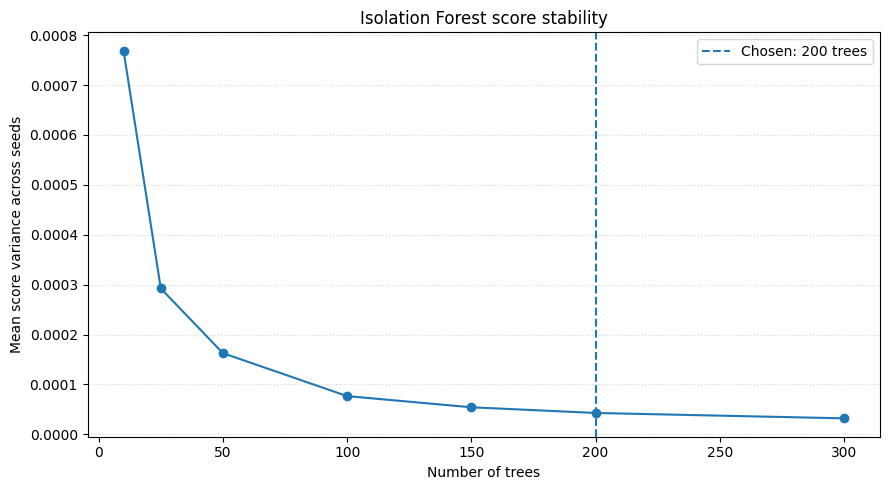

In [11]:
if RUN_IF_STABILITY_CHECK:
    tree_grid = [10, 25, 50, 100, 150, 200, 300]
    mean_score_variance = []

    for n_trees in tree_grid:
        repeated_scores = []

        for seed in range(5):
            model = IsolationForest(
                n_estimators=n_trees,
                contamination=CONTAMINATION,
                random_state=seed,
                max_samples="auto",
                n_jobs=-1,
            )
            model.fit(X_outlier)
            repeated_scores.append(-model.score_samples(X_outlier))

        mean_score_variance.append(
            float(np.mean(np.var(repeated_scores, axis=0)))
        )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(tree_grid, mean_score_variance, marker="o")
    ax.axvline(
        N_ESTIMATORS_IF,
        linestyle="--",
        label=f"Chosen: {N_ESTIMATORS_IF} trees",
    )
    ax.set_xlabel("Number of trees")
    ax.set_ylabel("Mean score variance across seeds")
    ax.set_title("Isolation Forest score stability")
    ax.legend()
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

### 6.1 Isolation path of the most anomalous record

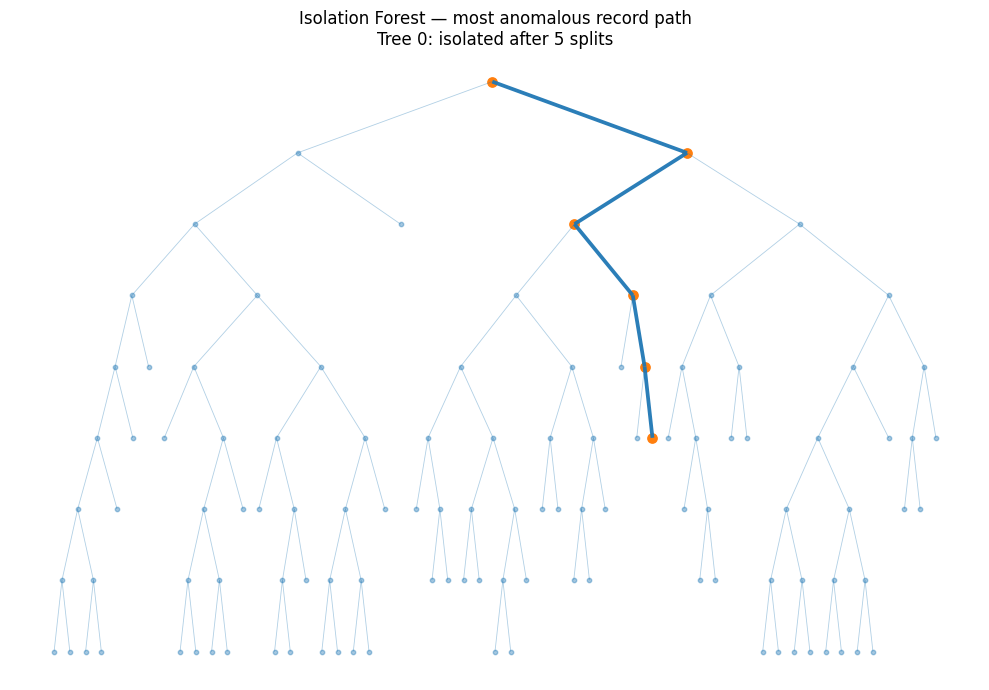

Worst IF row position: 3221
Isolation depth: 5


In [12]:
def tree_edges(tree):
    edges = []
    for node in range(tree.node_count):
        left = tree.children_left[node]
        right = tree.children_right[node]
        if left != -1:
            edges.append((node, left))
        if right != -1:
            edges.append((node, right))
    return edges

def tree_top_down_layout(tree):
    children_left = tree.children_left
    children_right = tree.children_right
    x_pos = {}
    y_pos = {}
    leaf_counter = [0]

    def recurse(node, depth):
        y_pos[node] = -depth
        left = children_left[node]
        right = children_right[node]

        if left == -1 and right == -1:
            x_pos[node] = leaf_counter[0]
            leaf_counter[0] += 1
            return

        child_positions = []
        for child in [left, right]:
            if child != -1:
                recurse(child, depth + 1)
                child_positions.append(x_pos[child])

        x_pos[node] = float(np.mean(child_positions))

    recurse(0, 0)
    return {node: (x_pos[node], y_pos[node]) for node in x_pos}

worst_if_position = int(
    if_positions[np.argmax(if_scores[if_positions])]
)

tree_number = 0
tree_estimator = if_model.estimators_[tree_number]
sample = X_outlier[worst_if_position].reshape(1, -1)
path_nodes = tree_estimator.decision_path(sample).indices.tolist()

tree = tree_estimator.tree_
coords = tree_top_down_layout(tree)
edges = tree_edges(tree)
path_edges = set(zip(path_nodes[:-1], path_nodes[1:]))

normal_segments = [
    [coords[a], coords[b]]
    for a, b in edges
    if (a, b) not in path_edges
]
highlight_segments = [
    [coords[a], coords[b]]
    for a, b in edges
    if (a, b) in path_edges
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.add_collection(
    LineCollection(normal_segments, linewidths=0.6, alpha=0.35)
)
ax.add_collection(
    LineCollection(highlight_segments, linewidths=2.7, alpha=0.95)
)

xy = np.array([coords[i] for i in range(tree.node_count)])
ax.scatter(xy[:, 0], xy[:, 1], s=10, alpha=0.4)

path_xy = np.array([coords[i] for i in path_nodes])
ax.scatter(path_xy[:, 0], path_xy[:, 1], s=45)

ax.set_title(
    "Isolation Forest — most anomalous record path\n"
    f"Tree {tree_number}: isolated after {len(path_nodes)-1} splits"
)
ax.set_axis_off()
ax.autoscale()
plt.tight_layout()
plt.show()

print("Worst IF row position:", worst_if_position)
print("Isolation depth:", len(path_nodes) - 1)

## 7. kNN — distance-based

In [13]:
knn_model = KNN(
    n_neighbors=N_NEIGHBORS,
    contamination=CONTAMINATION,
    method="largest",
    n_jobs=-1,
)
knn_model.fit(X_outlier)

knn_scores = knn_model.decision_scores_
knn_mask = top_fraction_mask(knn_scores)

print(
    f"kNN -> {knn_mask.sum()} outliers "
    f"({knn_mask.mean()*100:.2f}%)"
)
print(f"Score range: {knn_scores.min():.4f} - {knn_scores.max():.4f}")

kNN -> 84 outliers (1.00%)
Score range: 0.0008 - 19.7870


## 8. CBLOF — clustering-based

In [14]:
cblof_model = CBLOF(
    n_clusters=N_CLUSTERS_CBLOF,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
cblof_model.fit(X_outlier)

cblof_scores = cblof_model.decision_scores_
cblof_mask = top_fraction_mask(cblof_scores)

print(
    f"CBLOF -> {cblof_mask.sum()} outliers "
    f"({cblof_mask.mean()*100:.2f}%)"
)
print(f"Score range: {cblof_scores.min():.4f} - {cblof_scores.max():.4f}")

/var/folders/b4/hvnr8by950nd8ffj3bwdqh3w0000gn/T/ipykernel_29160/1820631056.py:7: FutureWarning: The 'n_jobs' parameter is deprecated and will be removed in PyOD v4.0.0. It has no effect on the default KMeans estimator. Control KMeans parallelism with the OMP_NUM_THREADS environment variable or threadpoolctl, or configure parallelism on a custom clustering_estimator.
  cblof_model.fit(X_outlier)


CBLOF -> 84 outliers (1.00%)
Score range: 0.7235 - 22.7167


## 9. Method comparison and consensus

Each detector contributes its own top 1%. The final removal threshold is **at least two detector votes**.

In [15]:
method_scores = {
    "LOF": lof_scores,
    "LODA": loda_scores,
    "Isolation Forest": if_scores,
    "KNN": knn_scores,
    "CBLOF": cblof_scores,
}

method_masks = {
    "LOF": lof_mask,
    "LODA": loda_mask,
    "Isolation Forest": if_mask,
    "KNN": knn_mask,
    "CBLOF": cblof_mask,
}

detector_summary = pd.DataFrame([
    summarize_detector(name, method_scores[name], method_masks[name])
    for name in method_scores
])

display(detector_summary.round(4))

flags = pd.DataFrame({
    f"flag_{name}": mask
    for name, mask in method_masks.items()
})
scores = pd.DataFrame({
    f"score_{name}": score
    for name, score in method_scores.items()
})

votes = flags.sum(axis=1).astype(int)
consensus_outlier = votes >= CONSENSUS_THRESHOLD

print("\nVote distribution:")
print(votes.value_counts().sort_index().to_string())

for threshold in range(1, len(method_masks) + 1):
    mask = votes >= threshold
    print(
        f"Threshold >= {threshold}: "
        f"{int(mask.sum())} rows ({mask.mean()*100:.2f}%)"
    )

print("\nFinal consensus outliers:", int(consensus_outlier.sum()))

,method,family,n_top_1pct,mean_score_outliers,mean_score_inliers,separation_ratio,min_selected_score,max_score
0,LOF,Density-based,84,124.4903,1.3558,91.8201,6.0578,2013.4556
1,LODA,Projection / histogram ensemble,84,0.0320,0.0205,1.5638,0.0295,0.0409
2,Isolation Forest,Tree ensemble,84,0.5726,0.4171,1.3729,0.5449,0.6535
3,KNN,Distance-based,84,9.7620,3.6778,2.6543,7.6763,19.7870
4,CBLOF,Clustering-based,84,11.8600,4.0918,2.8985,9.1435,22.7167



Vote distribution:
0    8144
1     142
2      69
3      24
4      17
Threshold >= 1: 252 rows (3.00%)
Threshold >= 2: 110 rows (1.31%)
Threshold >= 3: 41 rows (0.49%)
Threshold >= 4: 17 rows (0.20%)
Threshold >= 5: 0 rows (0.00%)

Final consensus outliers: 110


,LOF,LODA,Isolation Forest,KNN,CBLOF
LOF,84.0,0.0,0.0,0.0,0.0
LODA,0.0,84.0,54.0,38.0,32.0
Isolation Forest,0.0,54.0,84.0,27.0,22.0
KNN,0.0,38.0,27.0,84.0,70.0
CBLOF,0.0,32.0,22.0,70.0,84.0


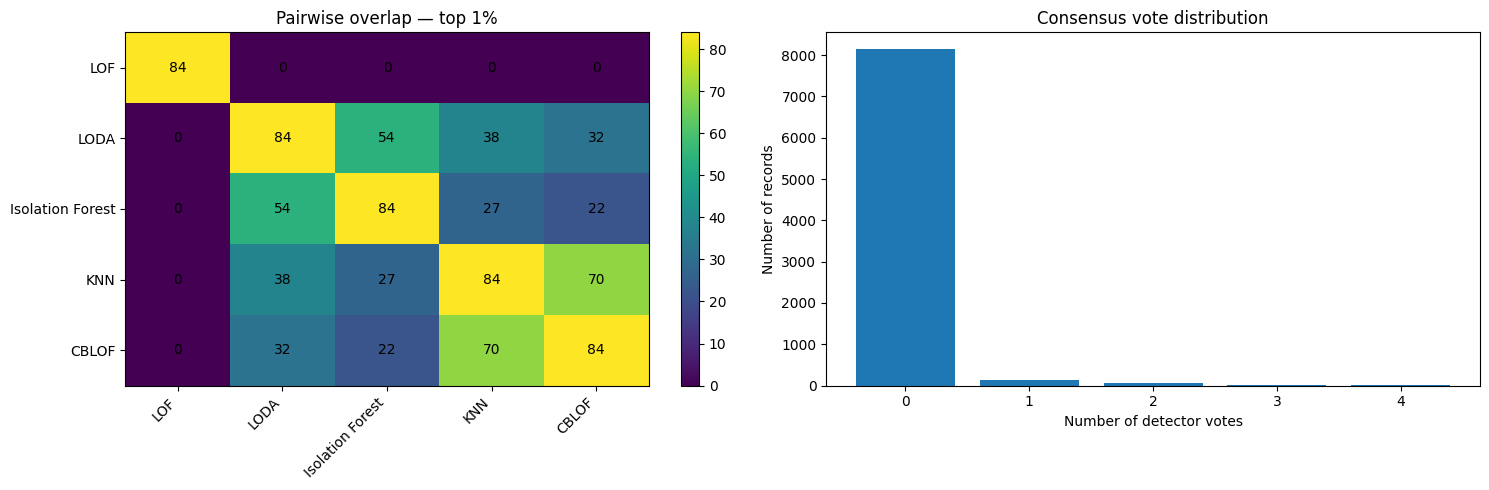

In [16]:
method_names = list(method_masks.keys())

overlap = pd.DataFrame(
    index=method_names,
    columns=method_names,
    dtype=int,
)

for a in method_names:
    for b in method_names:
        overlap.loc[a, b] = int(
            np.logical_and(method_masks[a], method_masks[b]).sum()
        )

display(overlap)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(overlap.to_numpy(), aspect="auto")
axes[0].set_xticks(
    range(len(method_names)),
    labels=method_names,
    rotation=45,
    ha="right",
)
axes[0].set_yticks(range(len(method_names)), labels=method_names)

for i in range(len(method_names)):
    for j in range(len(method_names)):
        axes[0].text(
            j, i, int(overlap.iloc[i, j]),
            ha="center", va="center"
        )

axes[0].set_title("Pairwise overlap — top 1%")
fig.colorbar(im, ax=axes[0])

vote_counts = votes.value_counts().sort_index()
axes[1].bar(vote_counts.index.astype(str), vote_counts.values)
axes[1].set_title("Consensus vote distribution")
axes[1].set_xlabel("Number of detector votes")
axes[1].set_ylabel("Number of records")

plt.tight_layout()
plt.show()

In [17]:
overlap_combinations = []

for size in range(2, len(method_names) + 1):
    for combo in combinations(method_names, size):
        combo_mask = np.ones(N, dtype=bool)

        for method in combo:
            combo_mask &= method_masks[method]

        n_common = int(combo_mask.sum())

        if n_common > 0:
            overlap_combinations.append({
                "n_methods": size,
                "methods": " ∩ ".join(combo),
                "n_common_records": n_common,
                "pct_dataset": n_common / N * 100,
            })

overlap_combinations_df = (
    pd.DataFrame(overlap_combinations)
    .sort_values(
        ["n_methods", "n_common_records"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(overlap_combinations_df.round(2))

,n_methods,methods,n_common_records,pct_dataset
0,4,LODA ∩ Isolation Forest ∩ KNN ∩ CBLOF,17,0.20
1,3,LODA ∩ KNN ∩ CBLOF,29,0.35
2,3,LODA ∩ Isolation Forest ∩ KNN,26,0.31
3,3,LODA ∩ Isolation Forest ∩ CBLOF,19,0.23
4,3,Isolation Forest ∩ KNN ∩ CBLOF,18,0.21
5,2,KNN ∩ CBLOF,70,0.83
6,2,LODA ∩ Isolation Forest,54,0.64
7,2,LODA ∩ KNN,38,0.45
8,2,LODA ∩ CBLOF,32,0.38
9,2,Isolation Forest ∩ KNN,27,0.32


## 10. Inspect consensus outliers and the rare severe class

The target is not used for anomaly detection. It is inspected only after the consensus has been formed to verify that the treatment does not remove the rarest class indiscriminately.

In [18]:
outlier_audit = pd.concat(
    [
        df_module0.reset_index(names="module0_row_index"),
        scores,
        flags,
    ],
    axis=1,
)

outlier_audit["n_detector_votes"] = votes.to_numpy()
outlier_audit["consensus_outlier"] = consensus_outlier.to_numpy()

consensus_rows = (
    outlier_audit.loc[outlier_audit["consensus_outlier"]]
    .sort_values("n_detector_votes", ascending=False)
)

display(consensus_rows.head(20))

,module0_row_index,sii,PCIAT-PCIAT_Total,Physical-BMI_recalc,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_GSND,FGC-FGC_GSD,FGC-FGC_PU,FGC-FGC_TL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_ECW,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,SDS-SDS_Total_Raw,PreInt_EduHx-computerinternet_hoursday,PAQ_Total,Fitness_Endurance-Time_Total_Sec,FGC-FGC_SR_Mean,FGC-FGC_SR_Asymmetry,score_LOF,score_LODA,score_Isolation Forest,score_KNN,score_CBLOF,flag_LOF,flag_LODA,flag_Isolation Forest,flag_KNN,flag_CBLOF,n_detector_votes,consensus_outlier
2398,2398,1.0,45.0,19.623053,18.0,0.0,65.0,73.00,148.75,29.0,71.0,104.0,116.0,5.0,19.0,52.75,46.50,51.0,13.0,4.0,8.321330,45.187100,8.907320,3.0,59.079700,44.0,2.0,2.0,446.0,15.5,3.0,1.435467,0.031998,0.598273,8.926908,11.665222,False,True,True,True,True,4,True
7568,7568,1.0,NaN,36.060561,16.0,1.0,59.0,64.25,211.75,30.0,75.0,84.0,115.0,4.0,0.0,38.75,29.50,0.0,10.0,1.0,4.788927,33.498981,61.616079,3.0,47.035345,58.0,3.0,2.0,388.0,7.0,14.0,1.468139,0.031949,0.578578,8.618152,9.724515,False,True,True,True,True,4,True
4690,4690,0.0,NaN,44.962106,15.0,0.0,51.0,54.00,186.50,28.0,75.0,98.0,110.0,5.0,6.0,57.25,1.75,38.0,11.0,2.0,17.906325,12.082062,8.578373,1.0,23.169549,45.0,2.0,2.0,387.0,10.0,0.0,2.253027,0.034079,0.578080,12.696678,13.897184,False,True,True,True,True,4,True
2008,2008,0.0,17.0,13.562587,9.0,1.0,70.0,49.75,47.75,26.0,86.0,79.0,116.0,6.0,115.0,20.00,22.25,19.0,13.0,5.0,8.109430,11.904700,1.849640,1.0,22.077400,33.0,0.0,4.0,572.0,14.0,0.0,1.664790,0.033936,0.546335,10.804897,14.330120,False,True,True,True,True,4,True
2193,2193,0.0,NaN,44.829216,14.0,1.0,65.0,66.50,282.00,49.0,80.0,99.0,152.0,5.0,0.0,39.00,46.25,0.0,9.0,3.0,4.597375,16.677558,25.914215,2.0,32.191454,45.0,0.0,2.0,448.0,0.0,0.0,1.501564,0.033864,0.577505,8.889677,10.031798,False,True,True,True,True,4,True
928,928,1.0,41.0,19.004109,17.0,0.0,60.0,68.00,125.00,28.0,52.0,46.0,111.0,5.0,55.0,34.25,34.50,47.0,7.0,4.0,6.614520,32.854700,16.418900,1.0,48.335500,43.0,3.0,5.0,448.0,5.5,1.0,1.288762,0.029898,0.549859,8.137562,11.597060,False,True,True,True,True,4,True
2309,2309,0.0,NaN,29.290347,16.0,0.0,62.0,74.50,231.25,44.0,64.0,79.0,119.0,5.0,10.0,35.50,34.25,0.0,12.0,3.0,8.336880,50.479700,75.325500,3.0,63.233300,39.0,2.0,2.0,448.0,7.5,15.0,1.484182,0.036928,0.594768,8.969341,10.405512,False,True,True,True,True,4,True
2326,2326,2.0,NaN,34.109011,17.0,0.0,65.0,69.00,231.00,40.0,86.0,82.0,142.0,5.0,0.0,81.25,106.00,0.0,0.0,3.0,3.922720,25.639902,16.174600,2.0,28.855800,46.0,3.0,2.0,448.0,0.0,0.0,1.664033,0.040867,0.606047,13.310821,16.877168,False,True,True,True,True,4,True
5774,5774,2.0,NaN,59.336680,6.0,0.0,63.0,48.25,196.50,42.0,55.0,96.0,94.0,5.0,0.0,17.00,0.75,2.0,3.0,1.0,6.831532,14.408692,37.754301,1.0,47.583864,35.0,0.0,3.0,513.0,1.5,3.0,1.465606,0.031160,0.561891,9.482019,11.632899,False,True,True,True,True,4,True
3427,3427,1.0,39.0,23.663870,17.0,0.0,87.0,72.00,174.50,31.0,70.0,107.0,131.0,5.0,78.0,44.00,39.75,30.0,11.0,4.0,7.584470,41.347700,42.677300,2.0,55.761000,39.0,0.0,2.0,448.0,12.0,2.0,1.321698,0.030396,0.604583,8.401030,10.977132,False,True,True,True,True,4,True


In [19]:
severe_mask = df_module0["sii"].to_numpy() == 3
critical_severe_mask = consensus_outlier.to_numpy() & severe_mask

n_severe = int(severe_mask.sum())
n_removed_severe = int(critical_severe_mask.sum())

print("Total severe-class records:", n_severe)
print("Severe consensus outliers:", n_removed_severe)

if n_severe:
    print(
        "Percentage of severe class removed:",
        f"{n_removed_severe / n_severe * 100:.2f}%"
    )

critical_positions = np.where(critical_severe_mask)[0]

if len(critical_positions):
    critical_table = outlier_audit.iloc[critical_positions].copy()
    display(
        critical_table[
            [
                "module0_row_index",
                "n_detector_votes",
                "sii",
                "PCIAT-PCIAT_Total",
            ]
            + feature_cols
        ]
    )

Total severe-class records: 88
Severe consensus outliers: 4
Percentage of severe class removed: 4.55%


,module0_row_index,n_detector_votes,sii,PCIAT-PCIAT_Total,Physical-BMI_recalc,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_GSND,FGC-FGC_GSD,FGC-FGC_PU,FGC-FGC_TL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_ECW,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,SDS-SDS_Total_Raw,PreInt_EduHx-computerinternet_hoursday,PAQ_Total,Fitness_Endurance-Time_Total_Sec,FGC-FGC_SR_Mean,FGC-FGC_SR_Asymmetry
306,306,4,3.0,89.0,46.095199,16.0,0.0,60.0,67.5,298.75,49.0,72.0,93.0,157.0,5.0,11.0,32.50,36.50,0.0,12.0,1.0,7.43478,58.7812,85.325384,3.0,73.2738,67.0,3.0,1.0,449.0,2.5,5.0
864,864,2,3.0,87.0,30.630714,12.0,0.0,55.0,70.0,213.50,33.0,50.0,79.0,121.0,5.0,20.0,23.00,28.25,3.0,15.0,4.0,6.57274,37.1307,87.672800,3.0,53.2215,56.0,3.0,3.0,448.0,4.0,2.0
2497,2497,2,3.0,88.0,33.425110,17.0,0.0,55.0,64.0,194.75,31.0,70.0,85.0,121.0,5.0,10.0,33.25,34.50,1.0,16.0,2.0,12.68840,37.7482,72.623300,3.0,53.4021,50.0,3.0,2.0,447.0,6.0,0.0
2655,2655,2,3.0,87.0,29.583059,19.0,0.0,75.0,77.5,252.75,26.0,65.0,60.0,128.0,5.0,9.0,20.00,24.50,6.0,10.0,1.0,9.30610,56.0236,79.570100,3.0,69.9321,42.0,3.0,2.0,448.0,8.5,1.0


## 11. Dimensionality reduction for visualization

PCA 2D explained variance: 32.45%
Components for >=80%: 15
Components for >=90%: 20


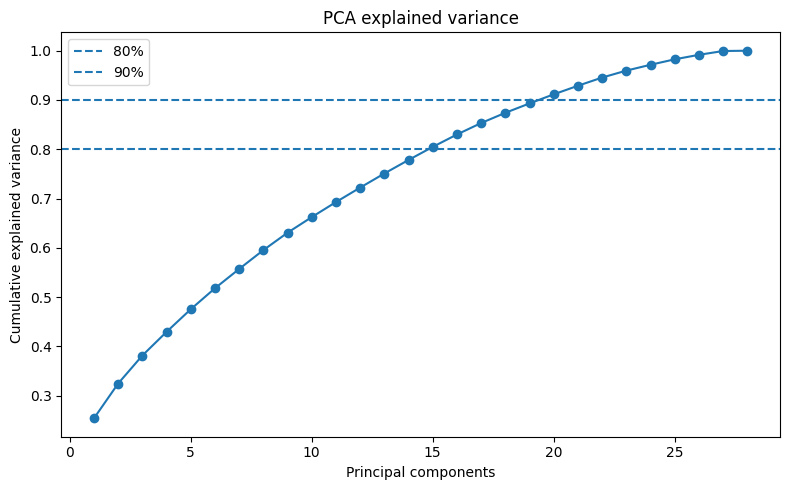

In [20]:
pca_full = PCA()
pca_full.fit(X_outlier)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = int(np.searchsorted(cumulative_variance, 0.80) + 1)
n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_outlier)

print(
    "PCA 2D explained variance:",
    f"{pca_2d.explained_variance_ratio_.sum()*100:.2f}%"
)
print("Components for >=80%:", n_components_80)
print("Components for >=90%:", n_components_90)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
)
ax.axhline(0.80, linestyle="--", label="80%")
ax.axhline(0.90, linestyle="--", label="90%")
ax.set_xlabel("Principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance")
ax.legend()
plt.tight_layout()
plt.show()

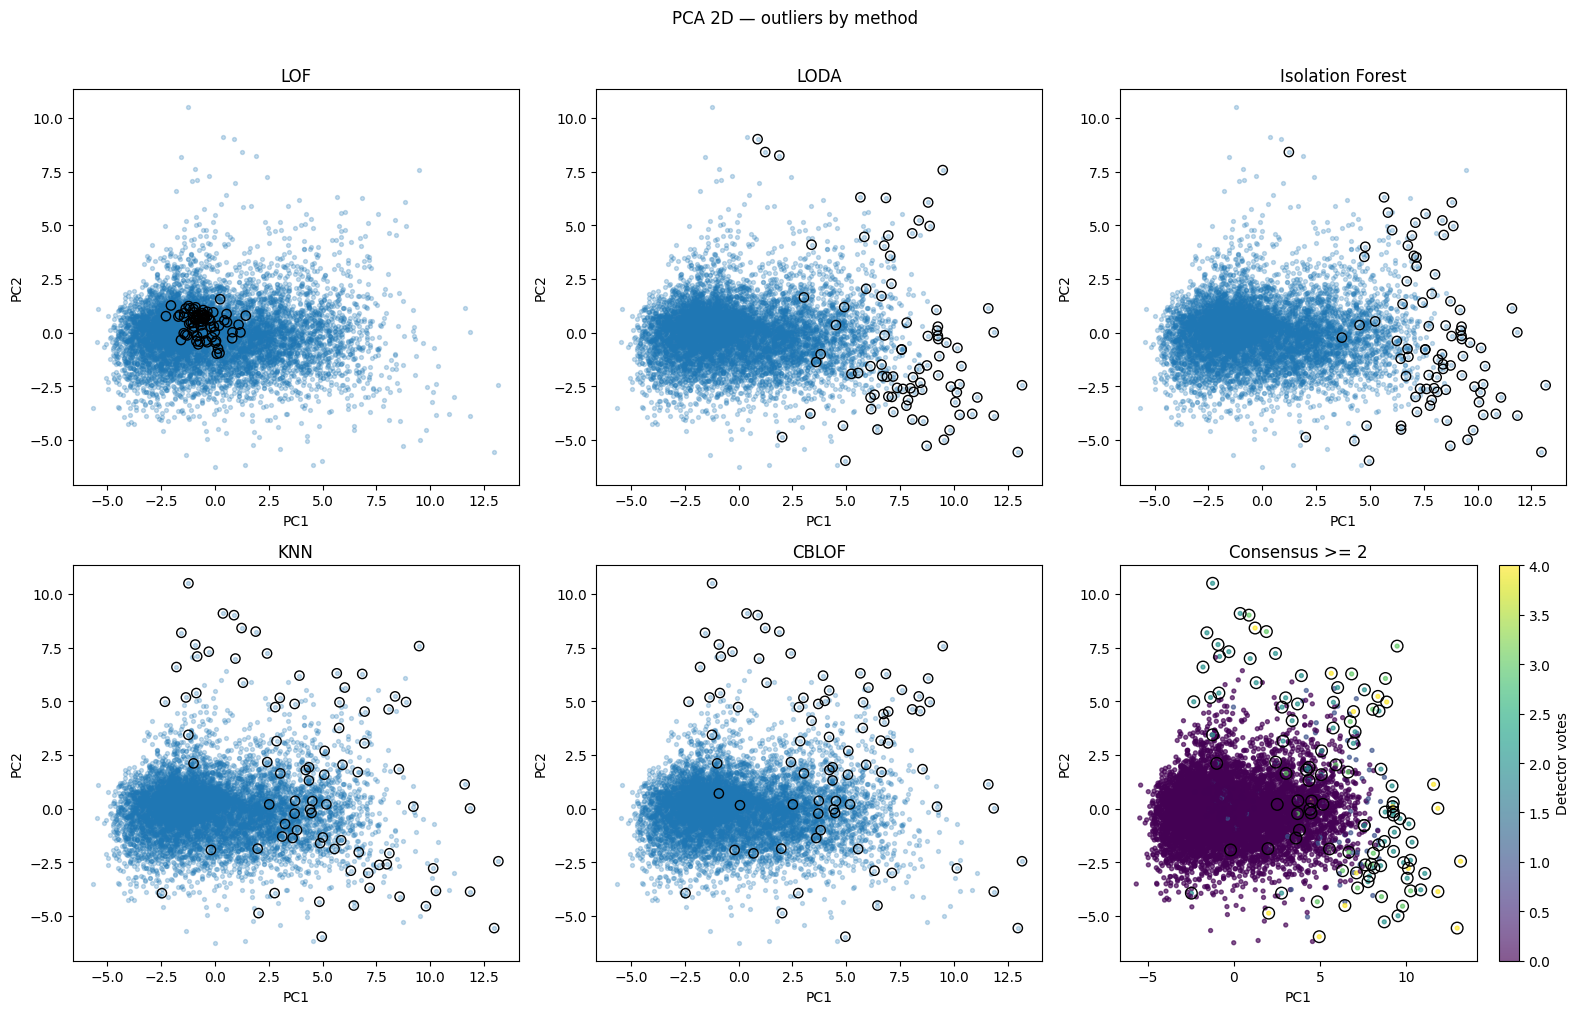

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, method_name in zip(axes, method_names):
    mask = method_masks[method_name]

    ax.scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        s=8,
        alpha=0.25,
    )
    ax.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=45,
        facecolors="none",
        edgecolors="black",
    )
    ax.set_title(method_name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

ax = axes[-1]
sc = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=votes,
    s=8,
    alpha=0.65,
)
ax.scatter(
    X_pca_2d[consensus_outlier, 0],
    X_pca_2d[consensus_outlier, 1],
    s=70,
    facecolors="none",
    edgecolors="black",
)
ax.set_title(f"Consensus >= {CONSENSUS_THRESHOLD}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
fig.colorbar(sc, ax=ax, label="Detector votes")

plt.suptitle("PCA 2D — outliers by method", y=1.01)
plt.tight_layout()
plt.show()

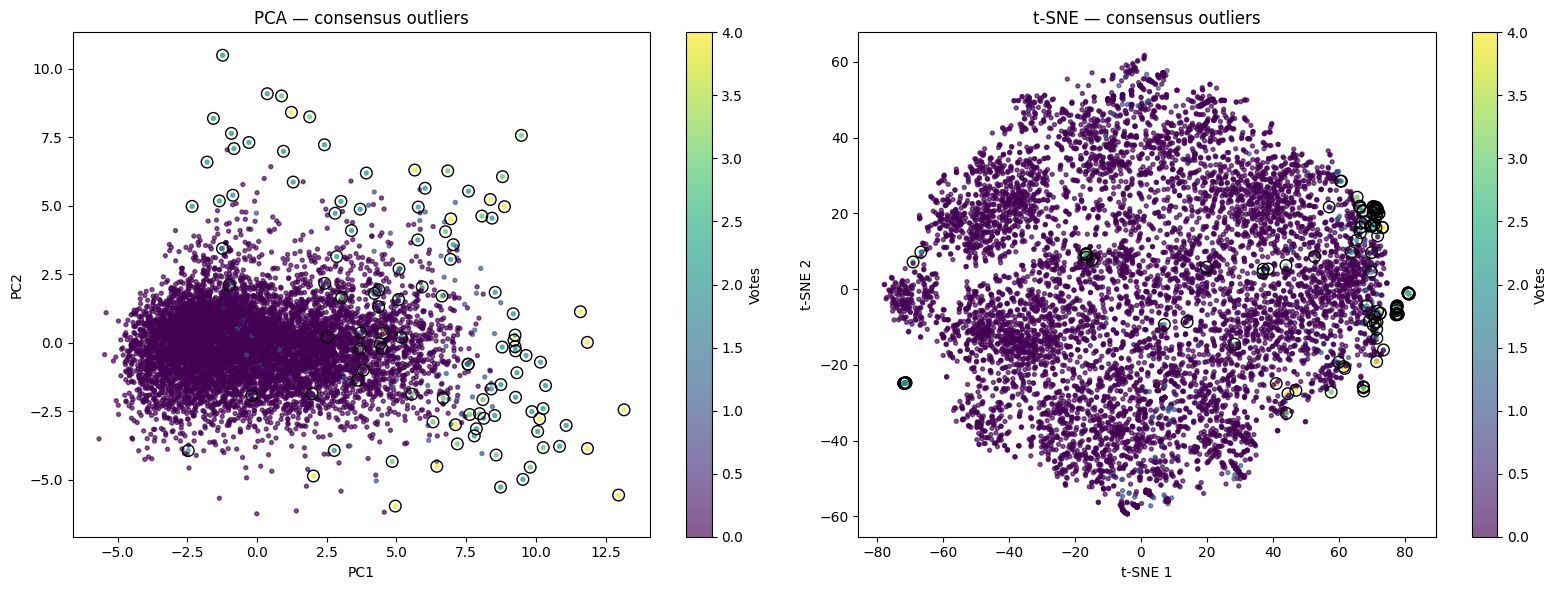

In [22]:
if RUN_TSNE:
    try:
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        tsne = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            n_iter=1000,
            random_state=RANDOM_STATE,
        )

    X_tsne_2d = tsne.fit_transform(X_outlier)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc0 = axes[0].scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        c=votes,
        s=8,
        alpha=0.65,
    )
    axes[0].scatter(
        X_pca_2d[consensus_outlier, 0],
        X_pca_2d[consensus_outlier, 1],
        s=70,
        facecolors="none",
        edgecolors="black",
    )
    axes[0].set_title("PCA — consensus outliers")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    fig.colorbar(sc0, ax=axes[0], label="Votes")

    sc1 = axes[1].scatter(
        X_tsne_2d[:, 0],
        X_tsne_2d[:, 1],
        c=votes,
        s=8,
        alpha=0.65,
    )
    axes[1].scatter(
        X_tsne_2d[consensus_outlier, 0],
        X_tsne_2d[consensus_outlier, 1],
        s=70,
        facecolors="none",
        edgecolors="black",
    )
    axes[1].set_title("t-SNE — consensus outliers")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    fig.colorbar(sc1, ax=axes[1], label="Votes")

    plt.tight_layout()
    plt.show()

## 12. Remove consensus outliers

In [23]:
def distribution_before_after(before, after, column):
    before_counts = before[column].value_counts(dropna=False).sort_index()
    after_counts = after[column].value_counts(dropna=False).sort_index()
    index = before_counts.index.union(after_counts.index)

    table = pd.DataFrame({
        "before_n": before_counts.reindex(index, fill_value=0),
        "after_n": after_counts.reindex(index, fill_value=0),
    })

    table["before_pct"] = table["before_n"] / len(before) * 100
    table["after_pct"] = table["after_n"] / len(after) * 100
    table["delta_pct_points"] = table["after_pct"] - table["before_pct"]

    return table

df_after_outliers = (
    df_module0.loc[~consensus_outlier.to_numpy()]
    .copy()
    .reset_index(drop=True)
)

print("Rows before:", len(df_module0))
print("Removed:", len(df_module0) - len(df_after_outliers))
print("Rows after:", len(df_after_outliers))
print("Shape:", df_after_outliers.shape)

display(
    distribution_before_after(
        df_module0,
        df_after_outliers,
        "sii",
    ).round(3)
)

if len(df_module0) == 8359:
    if int(consensus_outlier.sum()) != 106 or len(df_after_outliers) != 8253:
        warnings.warn(
            "Expected report checkpoint: 106 removed and 8,253 retained. "
            "Check Module 0 input and dependency versions."
        )

Rows before: 8396
Removed: 110
Rows after: 8286
Shape: (8286, 30)


,before_n,after_n,before_pct,after_pct,delta_pct_points
sii,,,,,
0.0,5769,5705,68.711,68.851,0.140
1.0,1587,1559,18.902,18.815,-0.087
2.0,952,938,11.339,11.320,-0.018
3.0,88,84,1.048,1.014,-0.034


## 13. Save outlier-cleaned data and audit artifacts

In [24]:
OUTLIER_CLEAN_DATASET_PATH = (
    PROCESSED_DIR / "06_module1_after_outlier_removal.csv"
)
OUTLIER_AUDIT_PATH = (
    ARTIFACT_DIR / "outlier_scores_and_flags.csv"
)
OUTLIER_SUMMARY_PATH = (
    ARTIFACT_DIR / "outlier_method_summary.csv"
)
OUTLIER_OVERLAP_PATH = (
    ARTIFACT_DIR / "outlier_pairwise_overlap.csv"
)

df_after_outliers.to_csv(OUTLIER_CLEAN_DATASET_PATH, index=False)
outlier_audit.to_csv(OUTLIER_AUDIT_PATH, index=False)
detector_summary.to_csv(OUTLIER_SUMMARY_PATH, index=False)
overlap.to_csv(OUTLIER_OVERLAP_PATH)

print("Saved:")
print("-", OUTLIER_CLEAN_DATASET_PATH)
print("-", OUTLIER_AUDIT_PATH)
print("-", OUTLIER_SUMMARY_PATH)
print("-", OUTLIER_OVERLAP_PATH)

Saved:
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/06_module1_after_outlier_removal.csv
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/outlier_scores_and_flags.csv
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/outlier_method_summary.csv
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/outlier_pairwise_overlap.csv


# Imbalanced Learning

The binary task follows the definition:

- **Mild:** `sii ∈ {0, 1}`
- **Severe:** `sii ∈ {2, 3}`

`PCIAT-PCIAT_Total` is removed from predictors to avoid direct leakage from the construct underlying `sii`.

## 14. Create the binary target

In [25]:
df_imbalanced = df_after_outliers.copy()

df_imbalanced["sii_Binary"] = np.where(
    df_imbalanced["sii"].isin([0, 1]),
    "Mild",
    "Severe",
)

binary_distribution = (
    df_imbalanced["sii_Binary"]
    .value_counts()
    .reindex(["Mild", "Severe"])
    .rename("count")
    .to_frame()
)

binary_distribution["percentage"] = (
    binary_distribution["count"] / len(df_imbalanced) * 100
)

display(binary_distribution.round(2))

X_binary = df_imbalanced.drop(
    columns=[
        "sii",
        "sii_Binary",
        "PCIAT-PCIAT_Total",
    ]
)

y_binary = df_imbalanced["sii_Binary"].copy()

print("Binary feature matrix:", X_binary.shape)

,count,percentage
sii_Binary,,
Mild,7264,87.67
Severe,1022,12.33


Binary feature matrix: (8286, 28)


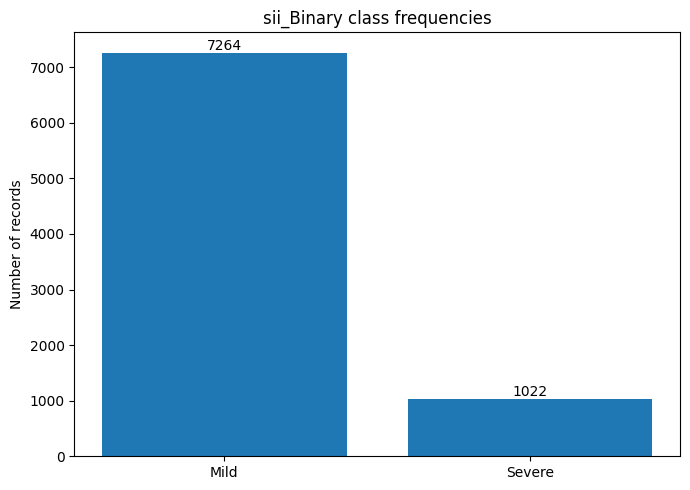

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = y_binary.value_counts().reindex(["Mild", "Severe"])
bars = ax.bar(counts.index, counts.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
    )

ax.set_title("sii_Binary class frequencies")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

## 15. Common split and train-only scaling

The final workflow uses a **70/30 stratified split** with `random_state=100`.

`MinMaxScaler` is fitted only on the training set. Every resampling technique is applied only to training data; the same untouched test set is used across methods.

In [27]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.30,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y_binary,
)

binary_scaler = MinMaxScaler()
X_train = binary_scaler.fit_transform(X_train_raw)
X_test = binary_scaler.transform(X_test_raw)

feature_names_binary = X_binary.columns.tolist()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train shape: (5800, 28)
Test shape: (2486, 28)
Train distribution: Counter({'Mild': 5085, 'Severe': 715})
Test distribution: Counter({'Mild': 2179, 'Severe': 307})


## 16. Shared evaluation functions

In [28]:
RESULT_ROWS = []

def evaluate_binary_model(
    name,
    model,
    X_eval,
    y_eval,
    family,
    train_distribution=None,
):
    y_pred = model.predict(X_eval)
    labels = ["Mild", "Severe"]

    precision, recall, f1, support = precision_recall_fscore_support(
        y_eval,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_eval,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )

    record = {
        "method": name,
        "family": family,
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "mild_precision": precision[0],
        "mild_recall": recall[0],
        "mild_f1": f1[0],
        "severe_precision": precision[1],
        "severe_recall": recall[1],
        "severe_f1": f1[1],
        "test_mild_support": int(support[0]),
        "test_severe_support": int(support[1]),
        "train_distribution": (
            str(train_distribution)
            if train_distribution is not None
            else ""
        ),
    }

    RESULT_ROWS.append(record)

    print(
        classification_report(
            y_eval,
            y_pred,
            labels=labels,
            zero_division=0,
        )
    )

    return record, y_pred

def fit_reference_dt(name, X_fit, y_fit, family):
    model = DecisionTreeClassifier(
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
    )
    model.fit(X_fit, y_fit)

    record, y_pred = evaluate_binary_model(
        name,
        model,
        X_test,
        y_test,
        family=family,
        train_distribution=Counter(y_fit),
    )

    return model, record, y_pred

## 17. Baseline Decision Tree

In [29]:
baseline_dt = DecisionTreeClassifier(
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)
baseline_dt.fit(X_train, y_train)

baseline_result, baseline_pred = evaluate_binary_model(
    "Baseline Decision Tree",
    baseline_dt,
    X_test,
    y_test,
    family="Unbalanced baseline",
    train_distribution=Counter(y_train),
)

baseline_proba = baseline_dt.predict_proba(X_test)

              precision    recall  f1-score   support

        Mild       0.89      0.90      0.89      2179
      Severe       0.20      0.18      0.19       307

    accuracy                           0.81      2486
   macro avg       0.54      0.54      0.54      2486
weighted avg       0.80      0.81      0.80      2486



,feature,importance
0,Physical-Height,0.098056
1,BIA-BIA_BMC,0.059672
2,SDS-SDS_Total_Raw,0.057674
3,Physical-Weight,0.056489
4,Physical-Diastolic_BP,0.053985
5,BIA-BIA_ICW,0.050870
6,FGC-FGC_CU,0.049070
7,Physical-HeartRate,0.046073
8,BIA-BIA_ECW,0.045231
9,CGAS-CGAS_Score,0.043562


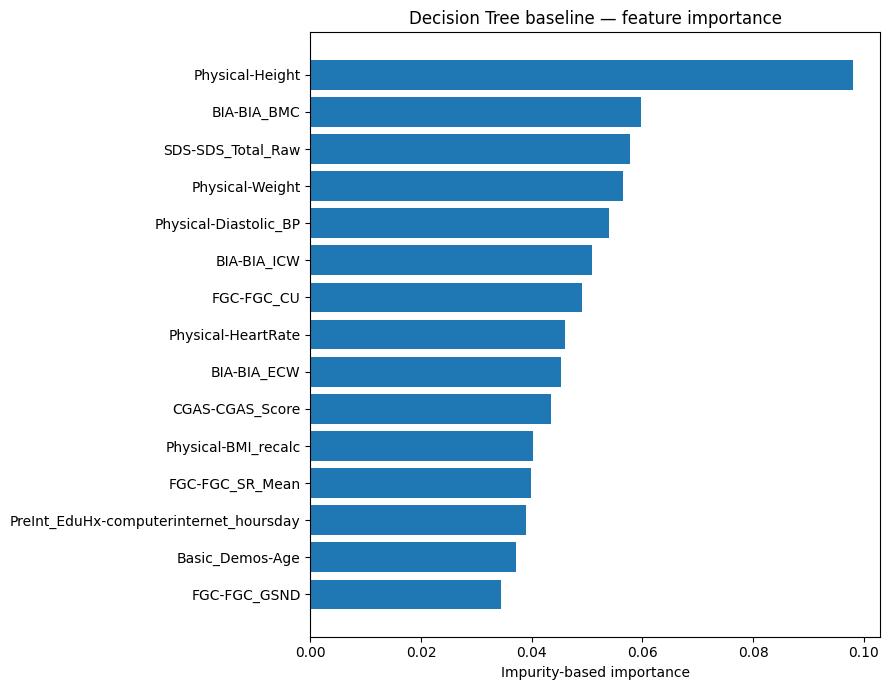

In [30]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_names_binary,
        "importance": baseline_dt.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15))

top_features = feature_importance.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_features["feature"], top_features["importance"])
ax.set_title("Decision Tree baseline — feature importance")
ax.set_xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()

## 18. Undersampling

The four techniques retained from the working notebooks are:

- Random Undersampling;
- Tomek Links;
- Edited Nearest Neighbours;
- Cluster Centroids.

In [31]:
undersamplers = {
    "Random Undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
    "Tomek Links": TomekLinks(),
    "Edited Nearest Neighbours": EditedNearestNeighbours(),
    "Cluster Centroids": ClusterCentroids(
        estimator=MiniBatchKMeans(n_init=1, random_state=0),
        random_state=RANDOM_STATE,
    ),
}

undersampled_data = {}

for name, sampler in undersamplers.items():
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    undersampled_data[name] = (X_resampled, y_resampled)

    print("\n" + "=" * 70)
    print(name)
    print("Training distribution:", Counter(y_resampled))

    fit_reference_dt(
        name,
        X_resampled,
        y_resampled,
        family="Undersampling",
    )


Random Undersampling
Training distribution: Counter({'Mild': 715, 'Severe': 715})
              precision    recall  f1-score   support

        Mild       0.92      0.60      0.73      2179
      Severe       0.18      0.62      0.28       307

    accuracy                           0.60      2486
   macro avg       0.55      0.61      0.50      2486
weighted avg       0.83      0.60      0.67      2486


Tomek Links
Training distribution: Counter({'Mild': 4953, 'Severe': 715})
              precision    recall  f1-score   support

        Mild       0.89      0.89      0.89      2179
      Severe       0.21      0.20      0.20       307

    accuracy                           0.81      2486
   macro avg       0.55      0.55      0.55      2486
weighted avg       0.80      0.81      0.81      2486


Edited Nearest Neighbours
Training distribution: Counter({'Mild': 3810, 'Severe': 715})
              precision    recall  f1-score   support

        Mild       0.89      0.82      0.85 

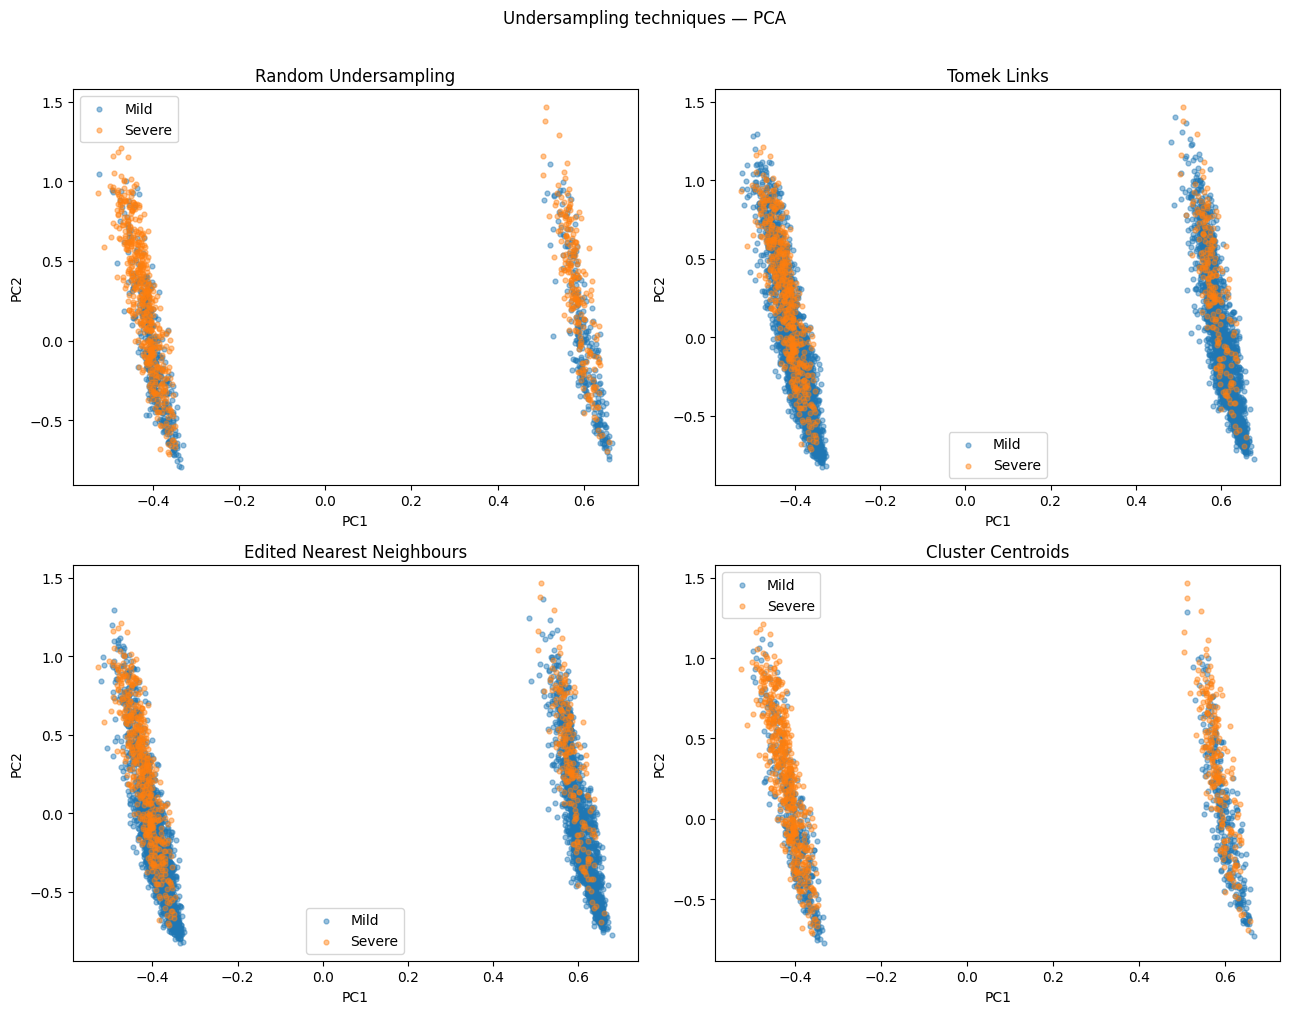

In [32]:
pca_under = PCA(n_components=2)
pca_under.fit(X_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, (name, (X_resampled, y_resampled)) in zip(
    axes,
    undersampled_data.items(),
):
    X_2d = pca_under.transform(X_resampled)
    y_array = np.asarray(y_resampled)

    for label in ["Mild", "Severe"]:
        mask = y_array == label
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            label=label,
            s=12,
            alpha=0.45,
        )

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.suptitle("Undersampling techniques — PCA", y=1.01)
plt.tight_layout()
plt.show()

## 19. Oversampling

The final exploration compares Random Oversampling, SMOTE and ADASYN.

In [33]:
oversamplers = {
    "Random Oversampling": RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "ADASYN": ADASYN(random_state=RANDOM_STATE),
}

oversampled_data = {}

for name, sampler in oversamplers.items():
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    oversampled_data[name] = (X_resampled, y_resampled)

    print("\n" + "=" * 70)
    print(name)
    print("Training distribution:", Counter(y_resampled))

    fit_reference_dt(
        name,
        X_resampled,
        y_resampled,
        family="Oversampling",
    )


Random Oversampling
Training distribution: Counter({'Mild': 5085, 'Severe': 5085})
              precision    recall  f1-score   support

        Mild       0.89      0.86      0.88      2179
      Severe       0.21      0.26      0.23       307

    accuracy                           0.79      2486
   macro avg       0.55      0.56      0.55      2486
weighted avg       0.81      0.79      0.80      2486


SMOTE
Training distribution: Counter({'Mild': 5085, 'Severe': 5085})
              precision    recall  f1-score   support

        Mild       0.89      0.83      0.86      2179
      Severe       0.19      0.28      0.23       307

    accuracy                           0.76      2486
   macro avg       0.54      0.56      0.55      2486
weighted avg       0.81      0.76      0.78      2486


ADASYN
Training distribution: Counter({'Mild': 5085, 'Severe': 4918})
              precision    recall  f1-score   support

        Mild       0.89      0.83      0.86      2179
      Severe

## 20. Algorithm-level balancing

We performed a grid search over `class_weight` and `min_samples_leaf`.

In [34]:
class_weight_grid = [
    {"Mild": 1, "Severe": 1},
    {"Mild": 2, "Severe": 1},
    {"Mild": 3, "Severe": 1},
    {"Mild": 1, "Severe": 2},
    {"Mild": 1, "Severe": 3},
]

algorithm_grid = {
    "class_weight": class_weight_grid,
    "min_samples_leaf": [1, 2, 3, 5],
}

algorithm_balance_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=algorithm_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy",
)

algorithm_balance_search.fit(X_train, y_train)

algorithm_balance_model = algorithm_balance_search.best_estimator_

print("Best source-grid parameters:", algorithm_balance_search.best_params_)

algorithm_balance_result, algorithm_balance_pred = evaluate_binary_model(
    "Algorithm-level class weighting",
    algorithm_balance_model,
    X_test,
    y_test,
    family="Algorithm-level balancing",
    train_distribution=Counter(y_train),
)

Best source-grid parameters: {'class_weight': {'Mild': 3, 'Severe': 1}, 'min_samples_leaf': 5}
              precision    recall  f1-score   support

        Mild       0.88      0.96      0.92      2179
      Severe       0.26      0.09      0.14       307

    accuracy                           0.86      2486
   macro avg       0.57      0.53      0.53      2486
weighted avg       0.81      0.86      0.82      2486



## 21. Final combined approach — ADASYN + ENN

ADASYN first focuses synthetic generation on difficult minority regions; ENN then removes locally inconsistent points. We used a Decision Tree with `max_depth=5` for this final hybrid experiment, and that decision is retained.

In [35]:
adasyn_hybrid = ADASYN(random_state=RANDOM_STATE)
X_adasyn, y_adasyn = adasyn_hybrid.fit_resample(X_train, y_train)

enn_hybrid = EditedNearestNeighbours()
X_hybrid_train, y_hybrid_train = enn_hybrid.fit_resample(
    X_adasyn,
    y_adasyn,
)

print("Original train:", Counter(y_train))
print("After ADASYN:", Counter(y_adasyn))
print("After ENN:", Counter(y_hybrid_train))

hybrid_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE,
)
hybrid_dt.fit(X_hybrid_train, y_hybrid_train)

hybrid_result, hybrid_pred = evaluate_binary_model(
    "ADASYN + ENN",
    hybrid_dt,
    X_test,
    y_test,
    family="Combined resampling",
    train_distribution=Counter(y_hybrid_train),
)

hybrid_proba = hybrid_dt.predict_proba(X_test)

Original train: Counter({'Mild': 5085, 'Severe': 715})
After ADASYN: Counter({'Mild': 5085, 'Severe': 4918})
After ENN: Counter({'Severe': 4918, 'Mild': 2724})
              precision    recall  f1-score   support

        Mild       0.92      0.63      0.74      2179
      Severe       0.19      0.61      0.29       307

    accuracy                           0.62      2486
   macro avg       0.55      0.62      0.52      2486
weighted avg       0.83      0.62      0.69      2486



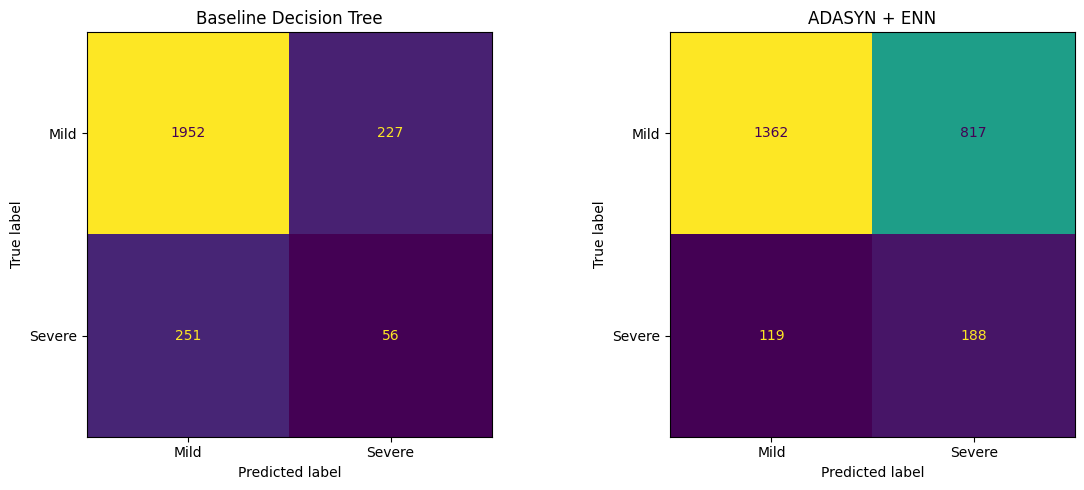

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred,
    labels=["Mild", "Severe"],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Baseline Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    hybrid_pred,
    labels=["Mild", "Severe"],
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("ADASYN + ENN")

plt.tight_layout()
plt.show()

### 21.1 ROC comparison — baseline vs hybrid

Here the hybrid ROC is correctly computed from `hybrid_dt.predict_proba(X_test)`.

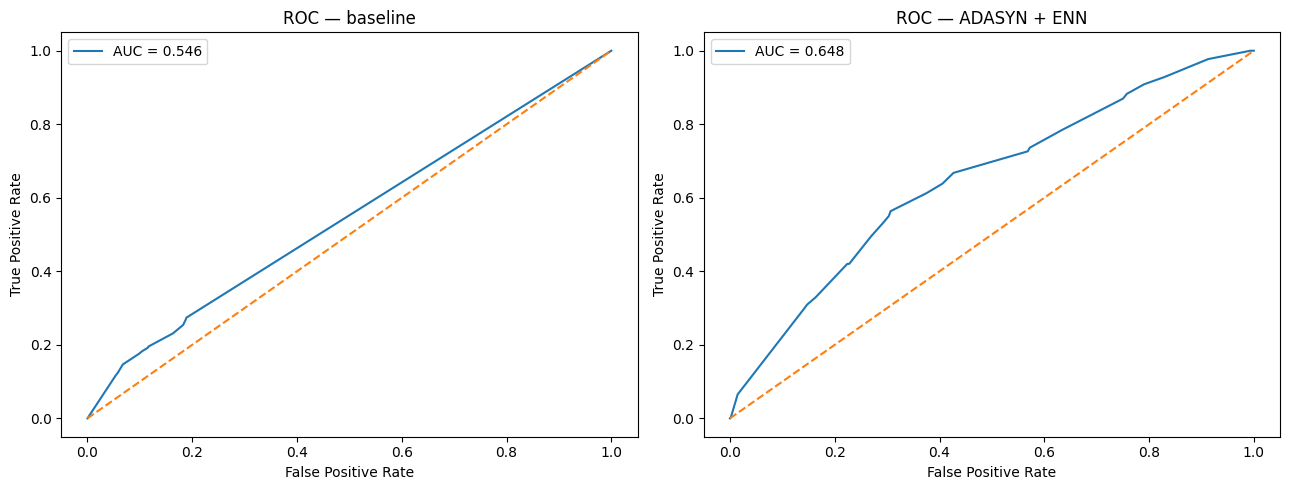

Baseline AUC: 0.5462
Hybrid AUC: 0.6485


In [37]:
positive_label = "Severe"

baseline_positive_index = list(baseline_dt.classes_).index(positive_label)
hybrid_positive_index = list(hybrid_dt.classes_).index(positive_label)

y_test_binary = y_test.eq(positive_label).astype(int).to_numpy()

baseline_severe_prob = baseline_proba[:, baseline_positive_index]
hybrid_severe_prob = hybrid_proba[:, hybrid_positive_index]

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test_binary,
    baseline_severe_prob,
)
hybrid_fpr, hybrid_tpr, _ = roc_curve(
    y_test_binary,
    hybrid_severe_prob,
)

baseline_auc = roc_auc_score(y_test_binary, baseline_severe_prob)
hybrid_auc = roc_auc_score(y_test_binary, hybrid_severe_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    baseline_fpr,
    baseline_tpr,
    label=f"AUC = {baseline_auc:.3f}",
)
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC — baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(
    hybrid_fpr,
    hybrid_tpr,
    label=f"AUC = {hybrid_auc:.3f}",
)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ROC — ADASYN + ENN")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Baseline AUC:", round(baseline_auc, 4))
print("Hybrid AUC:", round(hybrid_auc, 4))

## 22. Compare all imbalance strategies

Because the task is strongly imbalanced, class-specific metrics and macro averages are retained alongside accuracy.

In [38]:
imbalanced_results = (
    pd.DataFrame(RESULT_ROWS)
    .drop_duplicates(subset=["method"], keep="last")
    .sort_values(
        ["severe_recall", "macro_f1"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

metric_columns = [
    "method",
    "family",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "mild_precision",
    "mild_recall",
    "mild_f1",
    "severe_precision",
    "severe_recall",
    "severe_f1",
]

display(imbalanced_results[metric_columns].round(3))

,method,family,accuracy,macro_precision,macro_recall,macro_f1,mild_precision,mild_recall,mild_f1,severe_precision,severe_recall,severe_f1
0,Cluster Centroids,Undersampling,0.322,0.506,0.511,0.309,0.886,0.260,0.402,0.127,0.762,0.217
1,Random Undersampling,Undersampling,0.604,0.548,0.609,0.502,0.918,0.603,0.727,0.179,0.616,0.278
2,ADASYN + ENN,Combined resampling,0.623,0.553,0.619,0.515,0.920,0.625,0.744,0.187,0.612,0.287
3,Edited Nearest Neighbours,Undersampling,0.753,0.542,0.563,0.545,0.893,0.816,0.853,0.192,0.309,0.237
4,ADASYN,Oversampling,0.762,0.542,0.558,0.544,0.892,0.829,0.859,0.191,0.287,0.229
5,SMOTE,Oversampling,0.765,0.542,0.558,0.545,0.892,0.832,0.861,0.192,0.283,0.229
6,Random Oversampling,Oversampling,0.786,0.549,0.559,0.552,0.892,0.860,0.875,0.206,0.257,0.229
7,Tomek Links,Undersampling,0.806,0.548,0.547,0.547,0.888,0.891,0.890,0.207,0.202,0.205
8,Baseline Decision Tree,Unbalanced baseline,0.808,0.542,0.539,0.540,0.886,0.896,0.891,0.198,0.182,0.190
9,Algorithm-level class weighting,Algorithm-level balancing,0.856,0.572,0.527,0.528,0.883,0.964,0.921,0.262,0.091,0.135


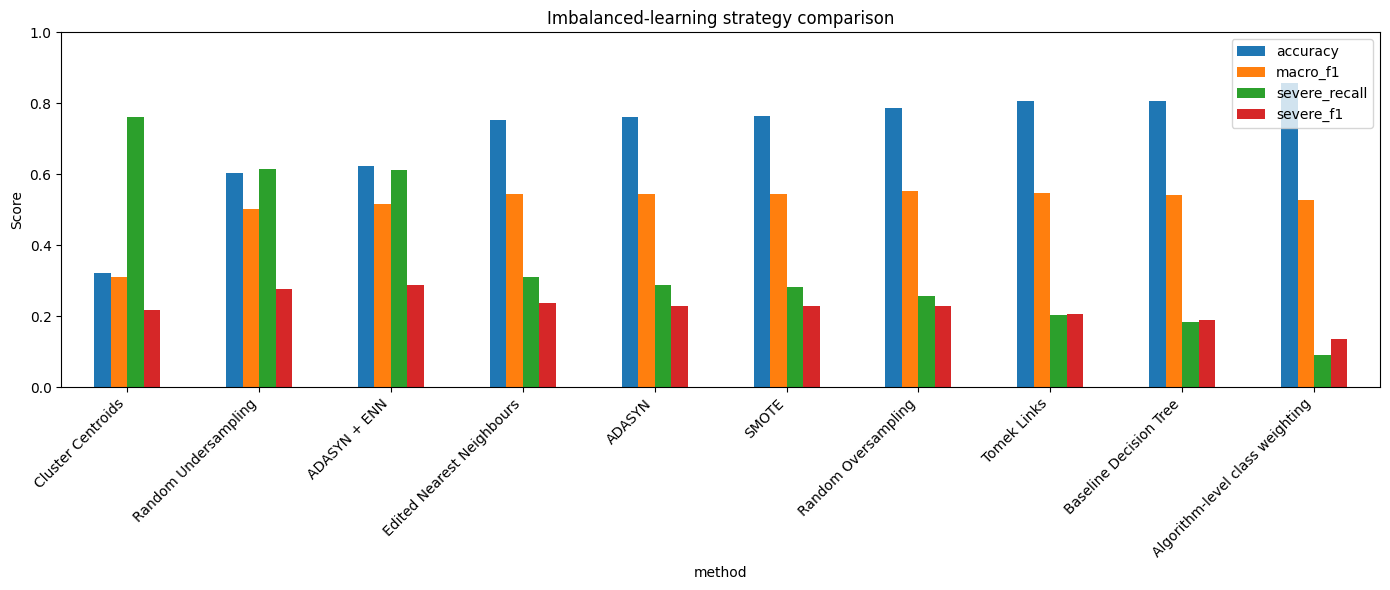

In [39]:
comparison_plot = (
    imbalanced_results[
        [
            "method",
            "accuracy",
            "macro_f1",
            "severe_recall",
            "severe_f1",
        ]
    ]
    .set_index("method")
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14, 6),
)
ax.set_title("Imbalanced-learning strategy comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 23. Save Module 1 outputs

The resampled training sets belong only to the imbalanced-learning experiment and are **not** passed to Module 2.

The downstream dataset remains the 30-column table after consensus-outlier removal.

In [40]:
IMBALANCED_RESULTS_PATH = ARTIFACT_DIR / "imbalanced_learning_results.csv"
BINARY_DISTRIBUTION_PATH = ARTIFACT_DIR / "sii_binary_distribution.csv"
ALGORITHM_GRID_RESULTS_PATH = ARTIFACT_DIR / "algorithm_level_grid_results.csv"

imbalanced_results.to_csv(IMBALANCED_RESULTS_PATH, index=False)
binary_distribution.to_csv(BINARY_DISTRIBUTION_PATH)
pd.DataFrame(algorithm_balance_search.cv_results_).to_csv(
    ALGORITHM_GRID_RESULTS_PATH,
    index=False,
)

print("Saved:")
print("-", IMBALANCED_RESULTS_PATH)
print("-", BINARY_DISTRIBUTION_PATH)
print("-", ALGORITHM_GRID_RESULTS_PATH)
print("\nDataset passed to Module 2:")
print("-", OUTLIER_CLEAN_DATASET_PATH)

Saved:
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/imbalanced_learning_results.csv
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/sii_binary_distribution.csv
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module1/algorithm_level_grid_results.csv

Dataset passed to Module 2:
- /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/06_module1_after_outlier_removal.csv
